# Inventory Management Simulation & Service Level Analysis

This notebook simulates an inventory system over a 52-week period. It compares a **Deterministic Baseline** (which assumes constant demand and lead times) against a **TSL-Augmented Model** (Target Service Level) that accounts for stochastic (random) variations in both demand and supplier lead times.

First, we will import our necessary libraries, set a random seed for reproducibility, and define our global parameters and environmental data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. GLOBAL PARAMETERS & DATA GENERATION
# ==========================================
np.random.seed(42) 
weeks = 52
holding_cost_per_unit = 2.50

# Stochastic Parameters
mean_demand = 100
std_dev_demand = 25
mean_lt = 2
std_dev_lt = 1

# Generate Environmental Data (Inputs)
actual_demand = np.maximum(0, np.random.normal(mean_demand, std_dev_demand, weeks).astype(int))
actual_lt = np.maximum(1, np.random.normal(mean_lt, std_dev_lt, weeks*2).round().astype(int))
total_annual_demand = np.sum(actual_demand)

print(f"Total Annual Demand Generated: {total_annual_demand} units")

Total Annual Demand Generated: 4893 units


## Time-Series Run: Deterministic vs. Stochastic (95% TSL)

In this section, we simulate the inventory levels week by week. 

1. **Deterministic Baseline:** Assumes no safety stock. Orders are placed to arrive exactly when mean demand dictates, which often leads to backorders when actual demand or lead times spike.
2. **TSL-Augmented Model:** Incorporates a Safety Stock ($SS$) designed to hit a 95% service level. 

The safety stock is calculated using the standard formula accounting for variability in both demand and lead time:
$$SS = Z \times \sqrt{\bar{L}\sigma_D^2 + \bar{D}^2\sigma_L^2}$$

In [2]:
# ==========================================
# 2. TIME-SERIES RUN (For Inventory Plot)
# ==========================================

# --- Deterministic Baseline ---
det_receipts = np.zeros(weeks + max(actual_lt))
for t in range(weeks):
    det_receipts[t + actual_lt[t]] += mean_demand

det_inv = 0
det_inv_history = np.zeros(weeks)
for i in range(weeks):
    det_inv += det_receipts[i]
    det_inv -= actual_demand[i] # Allows negative inventory (backorders)
    det_inv_history[i] = det_inv

# --- TSL-Augmented Model (Set at 95% for timeline comparison) ---
z_95 = stats.norm.ppf(0.95)
var_demand = mean_lt * (std_dev_demand ** 2)
var_lt = (mean_demand ** 2) * (std_dev_lt ** 2)
ss_95 = int(np.ceil(z_95 * np.sqrt(var_demand + var_lt)))

tsl_receipts_95 = np.zeros(weeks + max(actual_lt))
tsl_receipts_95[0] = ss_95 # Load safety stock
for t in range(weeks):
    tsl_receipts_95[t + actual_lt[t]] += mean_demand

tsl_inv = ss_95
tsl_inv_history_95 = np.zeros(weeks)
for i in range(weeks):
    tsl_inv += tsl_receipts_95[i]
    tsl_inv -= actual_demand[i]
    tsl_inv_history_95[i] = tsl_inv

## Sensitivity Analysis across Target Service Levels

Setting a higher target service level reduces stockouts but increases holding costs. Here, we iterate through target service levels from 50% to 99% to analyze:
* Actual achieved fill rates vs. Target fill rates.
* Total stockouts (missed units).
* Total annual holding costs.

In [3]:
# ==========================================
# 3. SENSITIVITY ANALYSIS (For Target Range Plots)
# ==========================================
target_levels = np.arange(0.50, 0.99, 0.02)
actual_fill_rates = []
total_holding_costs = []
total_stockouts_list = []

for tsl in target_levels:
    z_score = stats.norm.ppf(tsl) if tsl > 0.50 else 0
    safety_stock = int(np.ceil(z_score * np.sqrt(var_demand + var_lt)))
    
    tsl_receipts = np.zeros(weeks + max(actual_lt))
    tsl_receipts[0] = safety_stock 
    for t in range(weeks):
        tsl_receipts[t + actual_lt[t]] += mean_demand
            
    current_inv = safety_stock
    shortfalls = 0
    holding_cost = 0
    
    for i in range(weeks):
        current_inv += tsl_receipts[i]
        
        # Fulfilling demand
        if current_inv >= actual_demand[i]:
            current_inv -= actual_demand[i]
        else:
            shortfall = actual_demand[i] if current_inv < 0 else (actual_demand[i] - current_inv)
            shortfalls += shortfall
            current_inv -= actual_demand[i]
            
        # Calculate holding costs only on positive inventory
        if current_inv > 0:
            holding_cost += (current_inv * holding_cost_per_unit)
            
    # Record metrics for this TSL
    actual_fr = ((total_annual_demand - shortfalls) / total_annual_demand) * 100
    actual_fill_rates.append(actual_fr)
    total_stockouts_list.append(shortfalls)
    total_holding_costs.append(holding_cost)

## Generating the Visualizations

Finally, we plot our findings to visualize the system's performance and the financial trade-offs of holding inventory. 

**Plots included:**
1. Simulated Demand & Lead Times (Inputs)
2. Inventory Timeline Comparison (Baseline vs. 95% TSL)
3. Stockouts & Actual Fill Rates across TSLs
4. Total Holding Cost vs. TSL

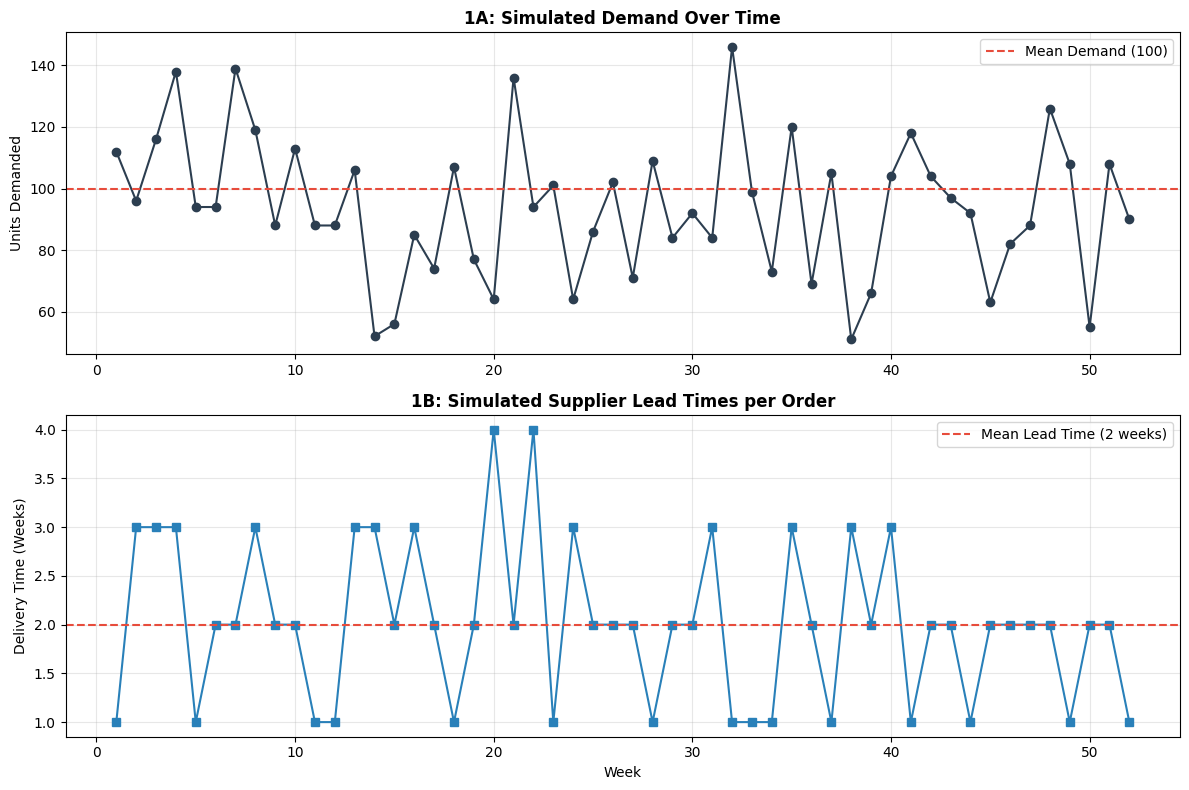

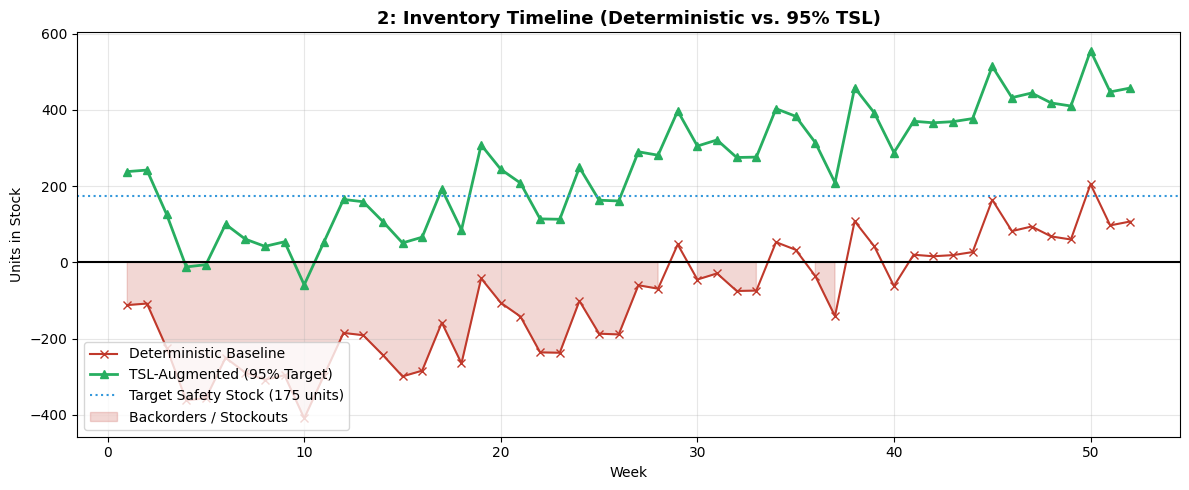

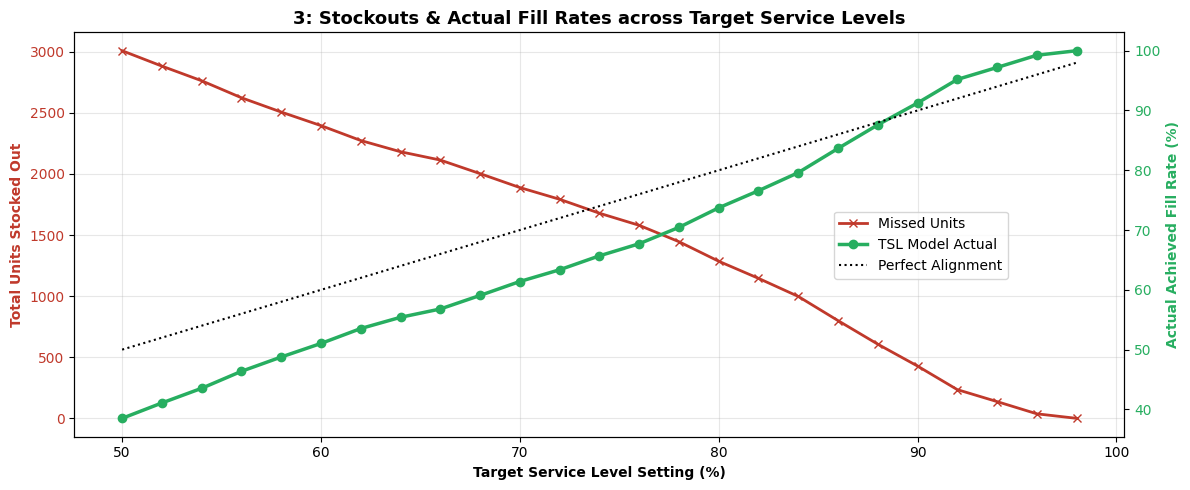

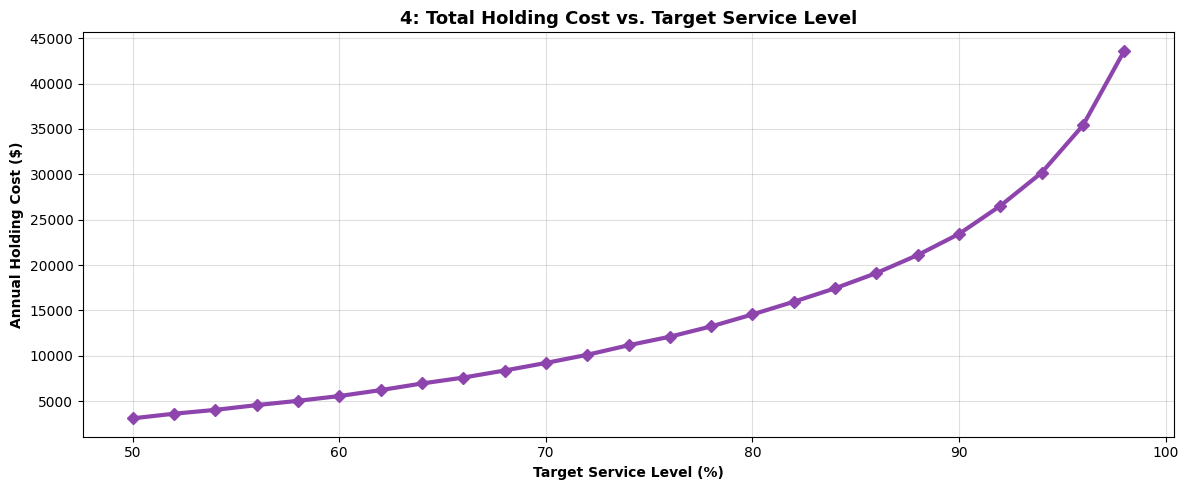

In [4]:
# ==========================================
# 4. GENERATING THE VISUALIZATIONS
# ==========================================

# --- PLOT 1: Inputs (Simulated Demand & Lead Times) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(range(1, weeks+1), actual_demand, marker='o', color='#2c3e50', linestyle='-')
ax1.axhline(y=mean_demand, color='#e74c3c', linestyle='--', label=f'Mean Demand ({mean_demand})')
ax1.set_title('1A: Simulated Demand Over Time', fontweight='bold')
ax1.set_ylabel('Units Demanded')
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.plot(range(1, weeks+1), actual_lt[:weeks], marker='s', color='#2980b9', linestyle='-')
ax2.axhline(y=mean_lt, color='#e74c3c', linestyle='--', label=f'Mean Lead Time ({mean_lt} weeks)')
ax2.set_title('1B: Simulated Supplier Lead Times per Order', fontweight='bold')
ax2.set_xlabel('Week'); ax2.set_ylabel('Delivery Time (Weeks)')
ax2.grid(True, alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()


# --- PLOT 2: Inventory Stock for Both Models Over Time ---
plt.figure(figsize=(12, 5))
plt.plot(range(1, weeks+1), det_inv_history, label='Deterministic Baseline', color='#c0392b', marker='x', linewidth=1.5)
plt.plot(range(1, weeks+1), tsl_inv_history_95, label='TSL-Augmented (95% Target)', color='#27ae60', marker='^', linewidth=2)
plt.axhline(y=0, color='black', linewidth=1.5)
plt.axhline(y=ss_95, color='#3498db', linestyle=':', label=f'Target Safety Stock ({ss_95} units)')
plt.fill_between(range(1, weeks+1), 0, det_inv_history, where=(det_inv_history < 0), color='#c0392b', alpha=0.2, label='Backorders / Stockouts')
plt.title('2: Inventory Timeline (Deterministic vs. 95% TSL)', fontsize=13, fontweight='bold')
plt.xlabel('Week'); plt.ylabel('Units in Stock')
plt.grid(True, alpha=0.3); plt.legend(loc='lower left')
plt.tight_layout(); plt.show()


# --- PLOT 3: Stockouts & Actual Fill Rate vs. TSL ---
fig, ax1 = plt.subplots(figsize=(12, 5))
color1 = '#c0392b'
ax1.set_xlabel('Target Service Level Setting (%)', fontweight='bold')
ax1.set_ylabel('Total Units Stocked Out', color=color1, fontweight='bold')
ax1.plot(target_levels * 100, total_stockouts_list, color=color1, linewidth=2, marker='x', label='Missed Units')
ax1.tick_params(axis='y', labelcolor=color1); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color2 = '#27ae60'
ax2.set_ylabel('Actual Achieved Fill Rate (%)', color=color2, fontweight='bold')  
ax2.plot(target_levels * 100, actual_fill_rates, color=color2, linewidth=2.5, marker='o', label='TSL Model Actual')
ax2.plot(target_levels * 100, target_levels * 100, color='black', linestyle=':', label='Perfect Alignment')
ax2.tick_params(axis='y', labelcolor=color2)
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5))
plt.title('3: Stockouts & Actual Fill Rates across Target Service Levels', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# --- PLOT 4: Holding Cost vs. Service Level ---
plt.figure(figsize=(12, 5))
plt.plot(target_levels * 100, total_holding_costs, color='#8e44ad', linewidth=3, marker='D')
plt.title('4: Total Holding Cost vs. Target Service Level', fontsize=13, fontweight='bold')
plt.xlabel('Target Service Level (%)', fontweight='bold')
plt.ylabel('Annual Holding Cost ($)', fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()